# Vahan — Lead-Source Cohort Performance & FT Conversion Model
### Product Analytics Internship Case Study

**By:** Yamini D


This notebook is organized into the three questions from the case study:
1. **Best-performing cohorts** — and the metric used to define "best"
2. **Aggregation query** — grain decision + SQL executed against the raw data
3. **ML model** — factors influencing FT, with leakage controls and a confusion matrix


In [20]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110


In [21]:
df = pd.read_excel('Vahan_Case_Study.xlsx', sheet_name='Raw Data')
print(df.shape)
df.head()


(18198, 19)


,upload_date,lead_source,candidate_phone,Uploaded Leads,Attempted,Connected,Attempt per Lead,tag_filled,Interested,OB_after_upload,OB_after_first_attempt,FT_after_upload,FT_after_first_attempt,upload_to_first_attempt_P50 (hrs),Attempted %,Attempt → Connected %,Connect → Interested %,Interested → FT_after_first_attempt %,Attempted → FT_after_upload %
0,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,91148e89d497914604c9c248ccd2aca212fac665bdc396...,1,1,1,1.0,1,0,0,0,0,0,112.0,100,100.0,0.0,NaN,0.0
1,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,4aa4e7a4f4a3b9fa608c4c1729be6a8accc31f58b3d8b1...,1,1,0,1.0,0,0,0,0,0,0,112.0,100,0.0,NaN,NaN,0.0
2,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,0e97e34090259c1ce6cef1fd1c491fcfc469ba9d2d1ce7...,1,1,0,1.0,0,0,0,0,0,0,89.0,100,0.0,NaN,NaN,0.0
3,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,cdc003718802cffa769a478bcc0fe31aa20ac3ffe97a7c...,1,1,0,1.0,0,0,0,0,0,0,106.0,100,0.0,NaN,NaN,0.0
4,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,d70833a770ab63e1992254dad148b100bbbadbe0e94673...,1,1,0,1.0,0,0,0,0,0,0,90.0,100,0.0,NaN,NaN,0.0


In [43]:
print("Unique lead sources:", df['lead_source'].nunique())
print("Unique upload dates:", df['upload_date'].nunique())
print("Unique candidate phones:", df['candidate_phone'].nunique())
print("total rows:", len(df))
print("\nDuplicate candidate rows (same phone appears more than once):", df['candidate_phone'].duplicated().sum())


Unique lead sources: 16
Unique upload dates: 11
Unique candidate phones: 17097
total rows: 18198

Duplicate candidate rows (same phone appears more than once): 1100


## Data Cleaning and Validation




In [23]:
checks = {}

# 1. Fully duplicate rows
checks['fully_duplicate_rows'] = df.duplicated().sum()

# 2. Binary flag columns outside {0,1}
flag_cols = ['Uploaded Leads','Attempted','Connected','tag_filled','Interested',
             'OB_after_upload','OB_after_first_attempt','FT_after_upload','FT_after_first_attempt']
checks['non_binary_flag_rows'] = sum((~df[c].isin([0,1])).sum() for c in flag_cols)

# 3. Funnel logic violations (an outcome flagged True without its prerequisite)
checks['FT_without_Attempted'] = len(df[(df['FT_after_upload']==1) & (df['Attempted']==0)])
checks['Connected_without_Attempted'] = len(df[(df['Connected']==1) & (df['Attempted']==0)])
checks['Interested_without_Connected'] = len(df[(df['Interested']==1) & (df['Connected']==0)])
checks['OB_without_Interested'] = len(df[(df['OB_after_upload']==1) & (df['Interested']==0)])

# 4. Missing candidate_phone (needed for candidate-level identity/splitting)
checks['null_candidate_phone'] = df['candidate_phone'].isnull().sum()

# 5. Negative time-to-first-attempt (physically impossible: attempt before upload)
checks['negative_P50_hours'] = (df['upload_to_first_attempt_P50 (hrs)'] < 0).sum()
checks['negative_P50_hours_pct_of_attempted'] = round(
    (df[df['Attempted']==1]['upload_to_first_attempt_P50 (hrs)'] < 0).mean() * 100, 2)

# 6. Unparseable dates
checks['unparseable_upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce').isnull().sum()

for k, v in checks.items():
    print(f"{k:45}: {v}")


fully_duplicate_rows                         : 0
non_binary_flag_rows                         : 0
FT_without_Attempted                         : 0
Connected_without_Attempted                  : 0
Interested_without_Connected                 : 0
OB_without_Interested                        : 116
null_candidate_phone                         : 1
negative_P50_hours                           : 1496
negative_P50_hours_pct_of_attempted          : 4.49
unparseable_upload_date                      : 0


In [44]:
df_clean = df.copy()
df_clean = df_clean[df_clean['candidate_phone'].notnull()].copy()

median_by_source = (
    df_clean[df_clean['upload_to_first_attempt_P50 (hrs)'] >= 0]
    .groupby('lead_source')['upload_to_first_attempt_P50 (hrs)']
    .median()
)
global_median = df_clean[df_clean['upload_to_first_attempt_P50 (hrs)'] >= 0]['upload_to_first_attempt_P50 (hrs)'].median()

def fix_p50(row):
    val = row['upload_to_first_attempt_P50 (hrs)']
    if pd.isnull(val) or val >= 0:
        return val
    return median_by_source.get(row['lead_source'], global_median)

df_clean['upload_to_first_attempt_P50 (hrs)'] = df_clean.apply(fix_p50, axis=1)

print(f"Rows before cleaning: {len(df)}  |  after cleaning: {len(df_clean)}")
print(f"Remaining negative P50 values: {(df_clean['upload_to_first_attempt_P50 (hrs)'] < 0).sum()}")



Rows before cleaning: 18198  |  after cleaning: 18197
Remaining negative P50 values: 0


## Question 1 — Which 3 cohorts are the best, and on what metric?

**Metric choice: end-to-end Uploaded → FT` conversion rate**, not raw FT count.

Why this metric over the alternatives:
- Raw FT count** rewards volume, not quality — a huge cohort with a poor rate would win purely on size, which isn't useful for deciding where to invest sourcing budget next*.
- Interested → FT rate only measures late-funnel execution and is blind to upstream lead quality.
- Uploaded → FT rate captures the entire funnel compounding together and is the closest proxy to sourcing ROI, since sourcing cost is typically incurred per lead.

**Reliability guard:** FT is rare (overall base rate is well under 1%), so a raw rate on a tiny cohort is statistically meaningless — a cohort with 2 leads and 1 FT is not "50% better." Two safeguards are applied:
1. A minimum volume floor (n ≥ 200 uploaded leads) before a cohort is eligible to be ranked at all.
2. Ranking is cross-checked against the Wilson score lower bound (95% CI) — a conservative estimate of the true rate that accounts for sample size, so it doesn't reward small-n noise.


In [25]:
def wilson_lower_bound(k, n, z=1.96):
    if n == 0:
        return 0.0
    p = k / n
    denom = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    adj = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return (centre - adj) / denom

cohort = df_clean.groupby('lead_source').agg(
    uploaded=('Uploaded Leads', 'sum'),
    attempted=('Attempted', 'sum'),
    connected=('Connected', 'sum'),
    interested=('Interested', 'sum'),
    ft_after_upload=('FT_after_upload', 'sum'),
    ft_after_first_attempt=('FT_after_first_attempt', 'sum'),
).reset_index()

cohort['ft_rate_pct'] = (cohort['ft_after_upload'] / cohort['uploaded'] * 100).round(3)
cohort['wilson_lb_pct'] = cohort.apply(
    lambda r: wilson_lower_bound(r['ft_after_upload'], r['uploaded']) * 100, axis=1).round(3)
cohort['attempted_pct'] = (cohort['attempted'] / cohort['uploaded'] * 100).round(1)

MIN_N = 200
eligible = cohort[cohort['uploaded'] >= MIN_N].sort_values('ft_rate_pct', ascending=False)
excluded = cohort[cohort['uploaded'] < MIN_N]

print(f"Excluded (n < {MIN_N}, too small to trust a rate):")
print(excluded[['lead_source', 'uploaded']].to_string(index=False))
print()
print("Eligible cohorts, ranked by FT rate (cross-checked by Wilson lower bound):")
eligible[['lead_source','uploaded','ft_after_upload','ft_rate_pct','wilson_lb_pct','attempted_pct']]


Excluded (n < 200, too small to trust a rate):
                      lead_source  uploaded
   50K 2W4 - Khanna - 2W - 17 Jul         1
   50K 2W5 - Khanna - 2W - 17 Jul         1
JobHai - Khanna - Riders - 16 Jul         2
JobHai - Khanna - Riders - 17 Jul         3

Eligible cohorts, ranked by FT rate (cross-checked by Wilson lower bound):


,lead_source,uploaded,ft_after_upload,ft_rate_pct,wilson_lb_pct,attempted_pct
15,Single Referral > 7 days- 24th Jul,1500,14,0.933,0.557,96.9
11,Khanna- 2W 26th Jul,1546,14,0.906,0.540,89.0
13,PreOb-Ob Fees Paid 29th Jul (set 1),1482,7,0.472,0.229,96.7
14,PreOb-Ob Fees Paid 29th Jul (set 2),1558,7,0.449,0.218,97.5
6,AI Connected but not Connected by TC- Set 1,1480,5,0.338,0.144,89.9
7,AI Connected but not Connected by TC- Set 2,1193,2,0.168,0.046,89.4
10,Khanna AI,886,1,0.113,0.020,27.7
12,OLX - Ashwin - 2W - 17 Jul,5182,4,0.077,0.030,18.6
5,AI Connected band Not Interested,2137,0,0.000,0.000,63.6
2,2W3W - 3WEV - Khanna - 3W - 17 Jul,201,0,0.000,0.000,100.0


In [26]:
# The two "PreOb-Ob Fees Paid" cohorts are the same initiative split across two upload batches
# (near-identical rates: confirm and combine for the final answer)
preob = cohort[cohort['lead_source'].str.contains('PreOb-Ob Fees Paid')]
combined_ft = preob['ft_after_upload'].sum()
combined_n = preob['uploaded'].sum()
print(preob[['lead_source','uploaded','ft_after_upload','ft_rate_pct']].to_string(index=False))
print(f"\nCombined as one program: {combined_ft} FT / {combined_n} uploaded = {combined_ft/combined_n*100:.2f}%")


                        lead_source  uploaded  ft_after_upload  ft_rate_pct
PreOb-Ob Fees Paid 29th Jul (set 1)      1482                7        0.472
PreOb-Ob Fees Paid 29th Jul (set 2)      1558                7        0.449

Combined as one program: 14 FT / 3040 uploaded = 0.46%


In [27]:
for keyword in ['Khanna', 'AI Connected', 'PreOb-Ob']:
    matches = sorted(s for s in df_clean['lead_source'].unique() if keyword.lower() in s.lower())
    print(f"Sources containing '{keyword}': {len(matches)}")
    for m in matches:
        print("  -", m)
    print()

Sources containing 'Khanna': 9
  - 2W3W - 3WAHD - Khanna - 3W - 17 Jul
  - 2W3W - 3WCNG - Khanna - 3W - 17 Jul
  - 2W3W - 3WEV - Khanna - 3W - 17 Jul
  - 50K 2W4 - Khanna - 2W - 17 Jul
  - 50K 2W5 - Khanna - 2W - 17 Jul
  - JobHai - Khanna - Riders - 16 Jul
  - JobHai - Khanna - Riders - 17 Jul
  - Khanna AI
  - Khanna- 2W 26th Jul

Sources containing 'AI Connected': 3
  - AI Connected band Not Interested
  - AI Connected but not Connected by TC- Set 1
  - AI Connected but not Connected by TC- Set 2

Sources containing 'PreOb-Ob': 2
  - PreOb-Ob Fees Paid 29th Jul (set 1)
  - PreOb-Ob Fees Paid 29th Jul (set 2)



**Result:** only "PreOb-Ob" is genuinely a pair (set 1 / set 2, combined above since their individual rates are nearly identical — 0.47% and 0.45%). "Khanna" actually spans **9** distinct campaigns and "AI Connected" spans **3** — these are kept fully separate everywhere in this analysis, since merging them would hide real performance differences between campaigns that happen to share a name.

### Funnel comparison — where do the top 3 cohorts actually lose people?

The final FT rate hides *where* in the funnel each cohort loses leads. This chart plots raw counts at each stage (Uploaded → Attempted → Connected → Interested → FT) for the top 3 cohorts side by side, on a log scale (since FT counts are two orders of magnitude smaller than Uploaded counts and would be invisible on a linear axis).

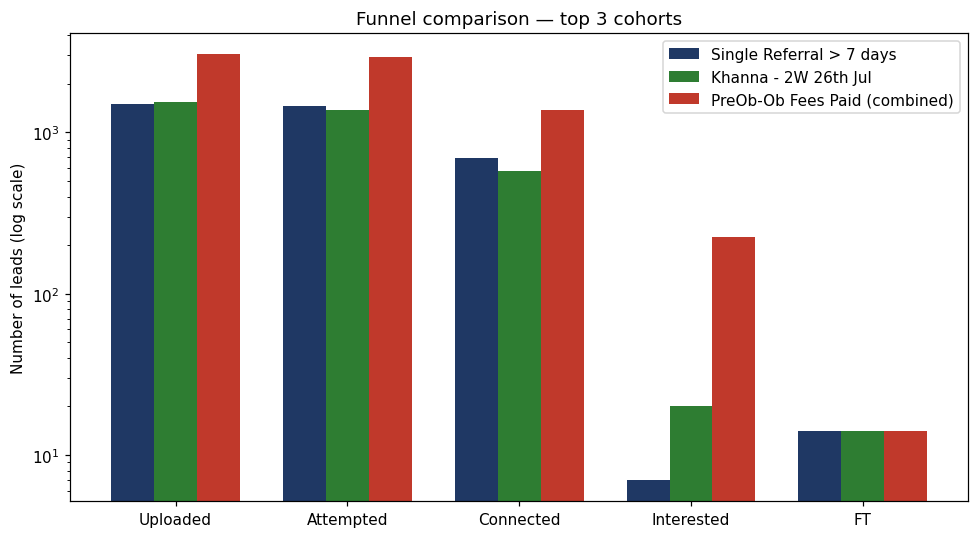

In [29]:
top3_sources = {
    'Single Referral > 7 days': cohort[cohort['lead_source'] == 'Single Referral > 7 days- 24th Jul'].iloc[0],
    'Khanna - 2W 26th Jul': cohort[cohort['lead_source'] == 'Khanna- 2W 26th Jul'].iloc[0],
}
preob_combined = cohort[cohort['lead_source'].str.contains('PreOb-Ob Fees Paid')][
    ['uploaded', 'attempted', 'connected', 'interested', 'ft_after_upload']
].sum()
top3_sources['PreOb-Ob Fees Paid (combined)'] = preob_combined

stages = ['uploaded', 'attempted', 'connected', 'interested', 'ft_after_upload']
stage_labels = ['Uploaded', 'Attempted', 'Connected', 'Interested', 'FT']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(stages))
width = 0.25
colors = ['#1F3864', '#2E7D32', '#C0392B']
for i, (name, row) in enumerate(top3_sources.items()):
    values = [max(row[s], 0.5) for s in stages]  # floor at 0.5 so log scale can plot it
    ax.bar(x + i * width, values, width, label=name, color=colors[i])

ax.set_yscale('log')
ax.set_xticks(x + width)
ax.set_xticklabels(stage_labels)
ax.set_ylabel('Number of leads (log scale)')
ax.set_title('Funnel comparison — top 3 cohorts')
ax.legend()
plt.tight_layout()
plt.savefig('funnel_top3.png', dpi=150, bbox_inches='tight')
plt.show()

## Question 2 — Aggregation query

Grain decision: lead_source, collapsing across upload_date



In [30]:
conn = sqlite3.connect(':memory:')
df_clean.to_sql('raw_data', conn, index=False, if_exists='replace')

query = '''
SELECT
    lead_source,
    COUNT(*)                                                          AS uploaded_leads,
    SUM(Attempted)                                                    AS attempted,
    SUM(Connected)                                                    AS connected,
    SUM(Interested)                                                   AS interested,
    SUM(FT_after_upload)                                              AS ft_after_upload,
    SUM(FT_after_first_attempt)                                       AS ft_after_first_attempt,
    ROUND(SUM(Attempted) * 100.0 / COUNT(*), 2)                       AS attempted_pct,
    ROUND(SUM(Connected) * 100.0 / NULLIF(SUM(Attempted), 0), 2)      AS attempt_to_connect_pct,
    ROUND(SUM(Interested) * 100.0 / NULLIF(SUM(Connected), 0), 2)     AS connect_to_interested_pct,
    ROUND(SUM(FT_after_upload) * 100.0 / COUNT(*), 2)                 AS ft_rate_pct
FROM raw_data
GROUP BY lead_source
HAVING COUNT(*) >= 200
ORDER BY ft_rate_pct DESC;
'''

agg_table = pd.read_sql_query(query, conn)
agg_table


,lead_source,uploaded_leads,attempted,connected,interested,ft_after_upload,ft_after_first_attempt,attempted_pct,attempt_to_connect_pct,connect_to_interested_pct,ft_rate_pct
0,Single Referral > 7 days- 24th Jul,1500,1454,690,7,14,2,96.93,47.46,1.01,0.93
1,Khanna- 2W 26th Jul,1546,1376,574,20,14,6,89.00,41.72,3.48,0.91
2,PreOb-Ob Fees Paid 29th Jul (set 1),1482,1433,650,103,7,2,96.69,45.36,15.85,0.47
3,PreOb-Ob Fees Paid 29th Jul (set 2),1558,1519,735,122,7,5,97.50,48.39,16.60,0.45
4,AI Connected but not Connected by TC- Set 1,1480,1331,694,29,5,0,89.93,52.14,4.18,0.34
5,AI Connected but not Connected by TC- Set 2,1193,1066,466,26,2,0,89.35,43.71,5.58,0.17
6,Khanna AI,886,245,137,2,1,0,27.65,55.92,1.46,0.11
7,OLX - Ashwin - 2W - 17 Jul,5182,962,372,9,4,2,18.56,38.67,2.42,0.08
8,AI Connected band Not Interested,2137,1359,637,21,0,0,63.59,46.87,3.30,0.00
9,2W3W - 3WEV - Khanna - 3W - 17 Jul,201,201,91,1,0,0,100.00,45.27,1.10,0.00


## Question 3 — ML model: what factors influence FT?




In [46]:
model_df = df_clean[df_clean['Attempted'] == 1].copy()

# Collapse rare lead_source categories to avoid sparse, overfit dummy variables
counts = model_df['lead_source'].value_counts()
rare = counts[counts < 50].index
model_df['lead_source_grp'] = model_df['lead_source'].where(~model_df['lead_source'].isin(rare), 'Other')

model_df['upload_date'] = pd.to_datetime(model_df['upload_date'])
model_df['upload_dow'] = model_df['upload_date'].dt.dayofweek

TARGET = 'FT_after_first_attempt'
FEATURES_NUM = ['Attempt per Lead', 'upload_to_first_attempt_P50 (hrs)', 'upload_dow']
FEATURES_CAT = ['lead_source_grp', 'Connected', 'tag_filled']

print(f"Modeling population (Attempted == 1): {len(model_df)} rows")
print(f"Target positive rate: {model_df[TARGET].mean()*100:.3f}% ({model_df[TARGET].sum()} FT out of {len(model_df)})")


Modeling population (Attempted == 1): 11973 rows
Target positive rate: 0.142% (17 FT out of 11973)


### Candidate-level train/test split

18,198 rows correspond to only ~17,098 unique candidate phone hashes — some candidates were uploaded more than once. A row-level random split could put the same person in both train and test, which is a subtle leakage path (the model could partially "memorize" a candidate rather than generalize). The split below is done at the **candidate level**, stratified by outcome so both sets contain positive examples despite FT being rare.


In [32]:
cand = model_df.groupby('candidate_phone')[TARGET].max().reset_index()
train_ids, test_ids = train_test_split(cand, test_size=0.3, stratify=cand[TARGET], random_state=42)

train = model_df[model_df['candidate_phone'].isin(train_ids['candidate_phone'])]
test  = model_df[model_df['candidate_phone'].isin(test_ids['candidate_phone'])]

print(f"Train: {len(train)} rows, {train[TARGET].sum()} positive")
print(f"Test:  {len(test)} rows, {test[TARGET].sum()} positive")

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train[TARGET]
X_test, y_test = test[FEATURES_NUM + FEATURES_CAT], test[TARGET]


Train: 8377 rows, 12 positive
Test:  3596 rows, 5 positive


In [33]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), FEATURES_CAT)
])

logreg = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
logreg.fit(X_train, y_train)

pred = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, pred)
print("Confusion Matrix (Logistic Regression, threshold = 0.5):")
print(cm)
print()
print(classification_report(y_test, pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))


Confusion Matrix (Logistic Regression, threshold = 0.5):
[[2779  812]
 [   1    4]]

              precision    recall  f1-score   support

           0      1.000     0.774     0.872      3591
           1      0.005     0.800     0.010         5

    accuracy                          0.774      3596
   macro avg      0.502     0.787     0.441      3596
weighted avg      0.998     0.774     0.871      3596

ROC-AUC: 0.819


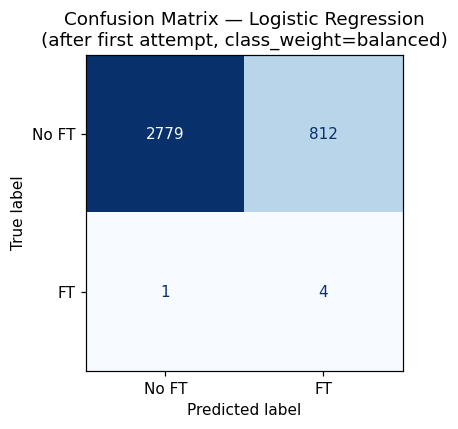

In [34]:
fig, ax = plt.subplots(figsize=(4.5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No FT', 'FT'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression\n(after first attempt, class_weight=balanced)')
plt.tight_layout()
plt.savefig('confusion_matrix_logreg.png', dpi=150)
plt.show()


In [36]:
rf = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=42))
])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, pred_rf)
print("Confusion Matrix (Random Forest, threshold = 0.5):")
print(cm_rf)
print()
print(classification_report(y_test, pred_rf, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 3))


Confusion Matrix (Random Forest, threshold = 0.5):
[[3458  133]
 [   4    1]]

              precision    recall  f1-score   support

           0      0.999     0.963     0.981      3591
           1      0.007     0.200     0.014         5

    accuracy                          0.962      3596
   macro avg      0.503     0.581     0.497      3596
weighted avg      0.997     0.962     0.979      3596

ROC-AUC: 0.776


In [37]:
cat_names = rf.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(FEATURES_CAT)
all_names = FEATURES_NUM + list(cat_names)

coef_df = pd.DataFrame({
    'feature': all_names,
    'logreg_coef': logreg.named_steps['clf'].coef_[0],
    'rf_importance': rf.named_steps['clf'].feature_importances_
}).sort_values('logreg_coef', ascending=False)

coef_df


,feature,logreg_coef,rf_importance
9,lead_source_grp_Khanna- 2W 26th Jul,3.206616,0.075310
14,lead_source_grp_Single Referral > 7 days- 24th...,3.030518,0.020852
13,lead_source_grp_PreOb-Ob Fees Paid 29th Jul (s...,2.520268,0.026923
12,lead_source_grp_PreOb-Ob Fees Paid 29th Jul (s...,2.298065,0.030439
16,tag_filled_1,1.792919,0.044497
10,lead_source_grp_OLX - Ashwin - 2W - 17 Jul,1.193753,0.017271
0,Attempt per Lead,1.150022,0.306590
11,lead_source_grp_Other,-0.012715,0.000003
4,lead_source_grp_2W3W - 3WEV - Khanna - 3W - 17...,-0.208980,0.000654
2,upload_dow,-0.525601,0.129533


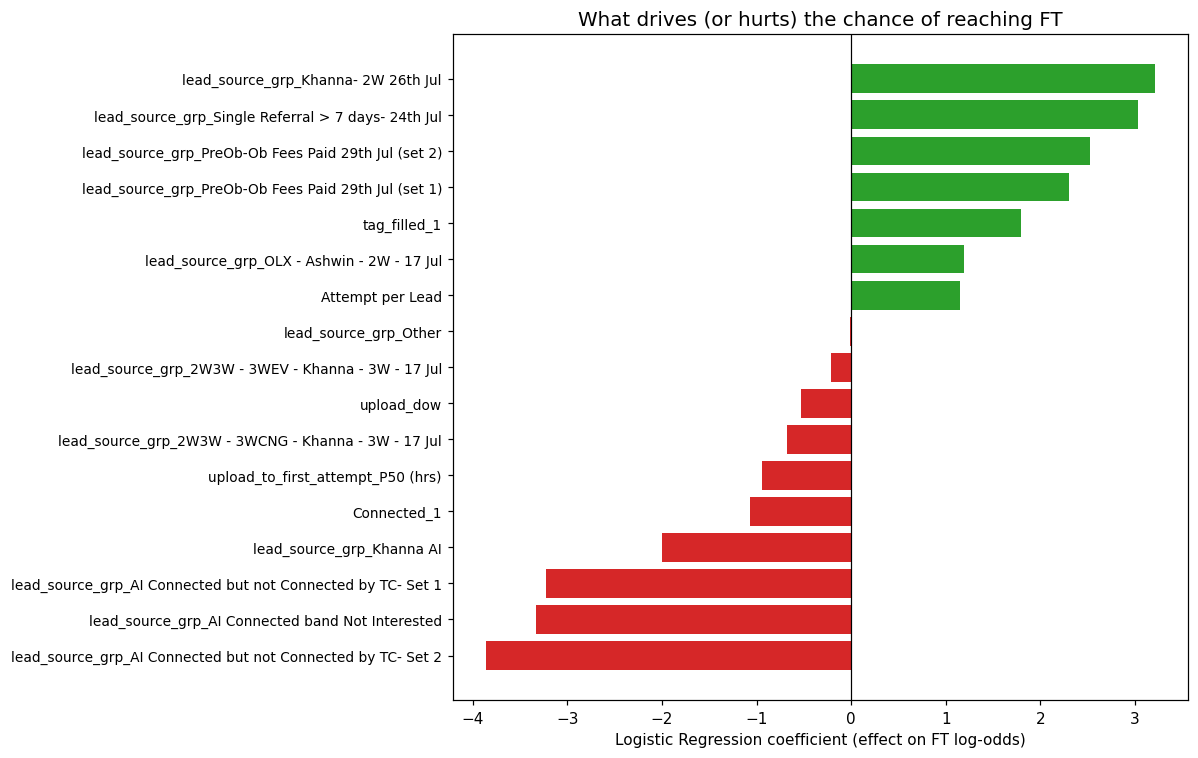

In [38]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = coef_df.sort_values('logreg_coef')
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df['logreg_coef']]
ax.barh(plot_df['feature'], plot_df['logreg_coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression coefficient (effect on FT log-odds)', fontsize=10)
ax.set_title('What drives (or hurts) the chance of reaching FT', fontsize=13)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
